<a href="https://colab.research.google.com/github/gcgauravchauhan10/gc_new_avenue/blob/main/Neural_Network_Keras_Sequential.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow import keras
from keras import layers
from keras import models
from keras.models import Sequential
from keras.layers import Dense

In [9]:
url = 'https://raw.githubusercontent.com/gcgauravchauhan10/artificial-intelligence-foundations-neural-networks-4381282/refs/heads/main/Advertising_2023.csv'
dfile = pd.read_csv(url, index_col=0)

In [10]:
dfile.head(5)

,digital,TV,radio,newspaper,sales
1,345.15,156.0,37.8,69.2,22.1
2,66.75,46.0,39.3,45.1,10.4
3,25.80,18.3,45.9,69.3,9.3
4,227.25,145.1,41.3,58.5,18.5
5,271.20,165.2,10.8,58.4,12.9


In [11]:
dfile.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1199 entries, 1 to 1197
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   digital    1199 non-null   float64
 1   TV         1199 non-null   float64
 2   radio      1199 non-null   float64
 3   newspaper  1199 non-null   float64
 4   sales      1199 non-null   float64
dtypes: float64(5)
memory usage: 56.2 KB


In [12]:
dfile.describe()

,digital,TV,radio,newspaper,sales
count,1199.000000,1199.00000,1199.000000,1199.000000,1199.000000
mean,135.472394,146.61985,23.240617,30.529942,14.005505
std,135.730821,85.61047,14.820827,21.712507,5.202804
min,0.300000,0.70000,0.000000,0.300000,1.600000
25%,24.250000,73.40000,9.950000,12.800000,10.300000
50%,64.650000,149.70000,22.500000,25.600000,12.900000
75%,256.950000,218.50000,36.500000,45.100000,17.400000
max,444.600000,296.40000,49.600000,114.000000,27.000000


In [15]:
dfile.shape

(1199, 5)

Check if any null values exist in dataset

In [17]:
dfile.isnull().sum()

,0
digital,0
TV,0
radio,0
newspaper,0
sales,0


Correlation Matrix

In [20]:
corr_matrix = dfile.corr()

In [21]:
corr_matrix

,digital,TV,radio,newspaper,sales
digital,1.000000,0.474256,0.041316,0.048023,0.380101
TV,0.474256,1.000000,0.055697,0.055579,0.781824
radio,0.041316,0.055697,1.000000,0.353096,0.576528
newspaper,0.048023,0.055579,0.353096,1.000000,0.227039
sales,0.380101,0.781824,0.576528,0.227039,1.000000


Heatmap form

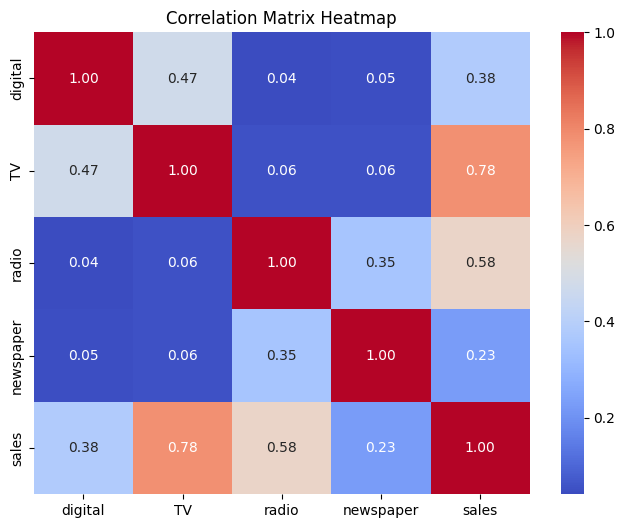

In [26]:
# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,      # show correlation values
    cmap="coolwarm", # color scheme
    fmt=".2f"        # 2 decimal places
)

plt.title("Correlation Matrix Heatmap")
plt.show()

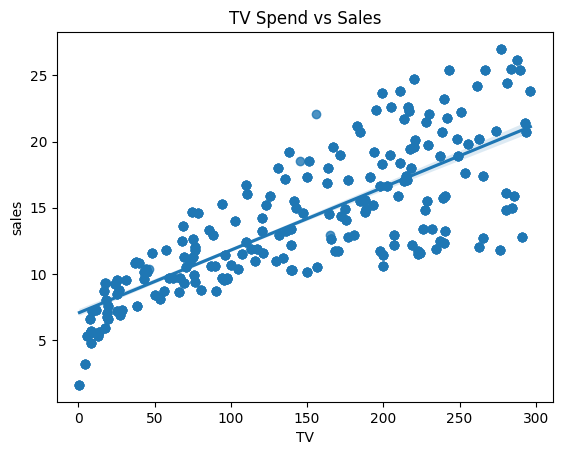

In [31]:
sns.regplot(data=dfile, x="TV", y="sales") ##regplot usedin place of scatterplot to add trendline
plt.title("TV Spend vs Sales")
plt.show()

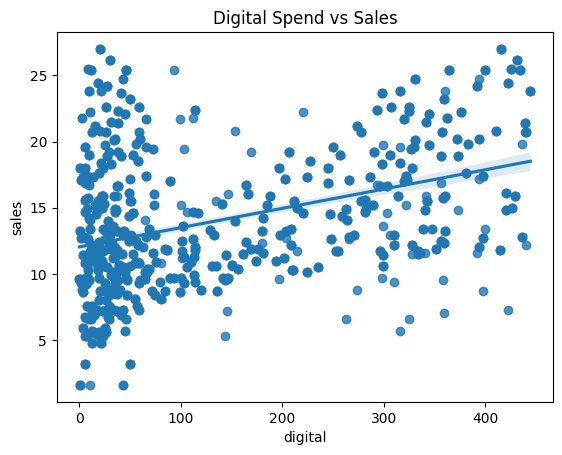

In [32]:
sns.regplot(data=dfile, x="digital", y="sales")
plt.title("Digital Spend vs Sales")
plt.show()

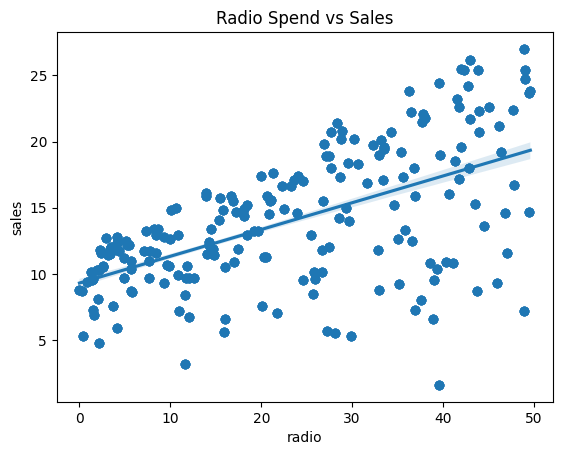

In [33]:
sns.regplot(data=dfile, x="radio", y="sales")
plt.title("Radio Spend vs Sales")
plt.show()

Scale the data : Normalization

In [41]:
x = dfile[['digital','TV','radio','newspaper']]
y = dfile['sales']

Normalization - If the inputs are not similar, it is difficult to initialize neural network. If you feed into neural network the values that have widely diff ranges. The model may be able to adapt but it will make learning mor difficult as it will cause bias in neuron calculations (Z1=W1X1 + W2X2 + B)

In [43]:
normalized_feature = keras.utils.normalize(x.values)
normalized_feature

array([[0.89211961, 0.4032179 , 0.0977028 , 0.17886333],
       [0.66254734, 0.45658693, 0.39008405, 0.44765371],
       [0.29009225, 0.20576311, 0.51609436, 0.77920128],
       ...,
       [0.06744611, 0.99272247, 0.05163843, 0.08536149],
       [0.19480049, 0.91868871, 0.08898294, 0.33188231],
       [0.06744611, 0.99272247, 0.05163843, 0.08536149]])

Import train test split function from sklearn.model_selection

In [44]:
from sklearn.model_selection import train_test_split

In [45]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.4,random_state=101)

In [50]:
print(x_train.shape, x_test.shape, y_train.shape, y_test.shape)

(719, 4) (480, 4) (719,) (480,)


#Build the model

In [54]:
model = Sequential()
model.add(Dense(4,activation='relu')) ## Dense refers to a fully connected layer
model.add(Dense(3,activation='relu'))
model.add(Dense(1))